<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-03/trabalho-03/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Equipe**: 01<br>
> **Estudantes**: Cristina Siewert Jansen, Marlon Sbardelatti e Sofia Sousa Lindner

# PARTE 2: Algoritmo Árvores de Decisão

In [123]:
FEATURE_NAMES = ['historia', 'divida', 'garantia', 'renda']
CLASS_NAMES = ['alto', 'baixo', 'moderado']

Nesta segunda parte do Trabalho você irá aplicar os algoritmos de Árvore de Decisão e de Floresta Aleatória na base de dados de risco de crédito discutida em aula. Para isso você deve primeiramente importar as bibliotecas necessárias.

In [124]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 1 - Importação dos dados Pré-Processados

a) importe o arquivo salvo como 'risco_credito.pkl'



In [125]:
import pickle
with open('risco_credito.pkl', 'rb') as f:
  X_risco_credito, y_risco_credito = pickle.load(f)

# 2 - Algoritmo de Árvore de Decisão



a) importar da biblioteca sklearn o pacote DecisionTreeClassifier

In [126]:
from sklearn.tree import DecisionTreeClassifier

b) Calcule a árvore de decisão, utilizando como critério a entropia.
Coloque como nome da variável: arvore_risco_credito

In [127]:
decision_tree_classifier = DecisionTreeClassifier(criterion='entropy')

arvore_risco_credito = decision_tree_classifier.fit(X_risco_credito, y_risco_credito)

c) Utilize o feature_importances_ para retornar a importância de cada atributo. Qual possui o maior ganho de informação?

In [128]:
for feature, importance in zip(FEATURE_NAMES, arvore_risco_credito.feature_importances_):
  print(f'{feature} -> {importance}')

historia -> 0.41391642688275077
divida -> 0.064086360970871
garantia -> 0.038854314802965445
renda -> 0.4831428973434129


O atributo de maior importância é a renda (0.48).

d) Gere uma visualização da sua árvore de decisão utilizando o pacote tree da biblioteca do sklearn.

OBS: Adicione cores, nomes para os atributos e para as classes.

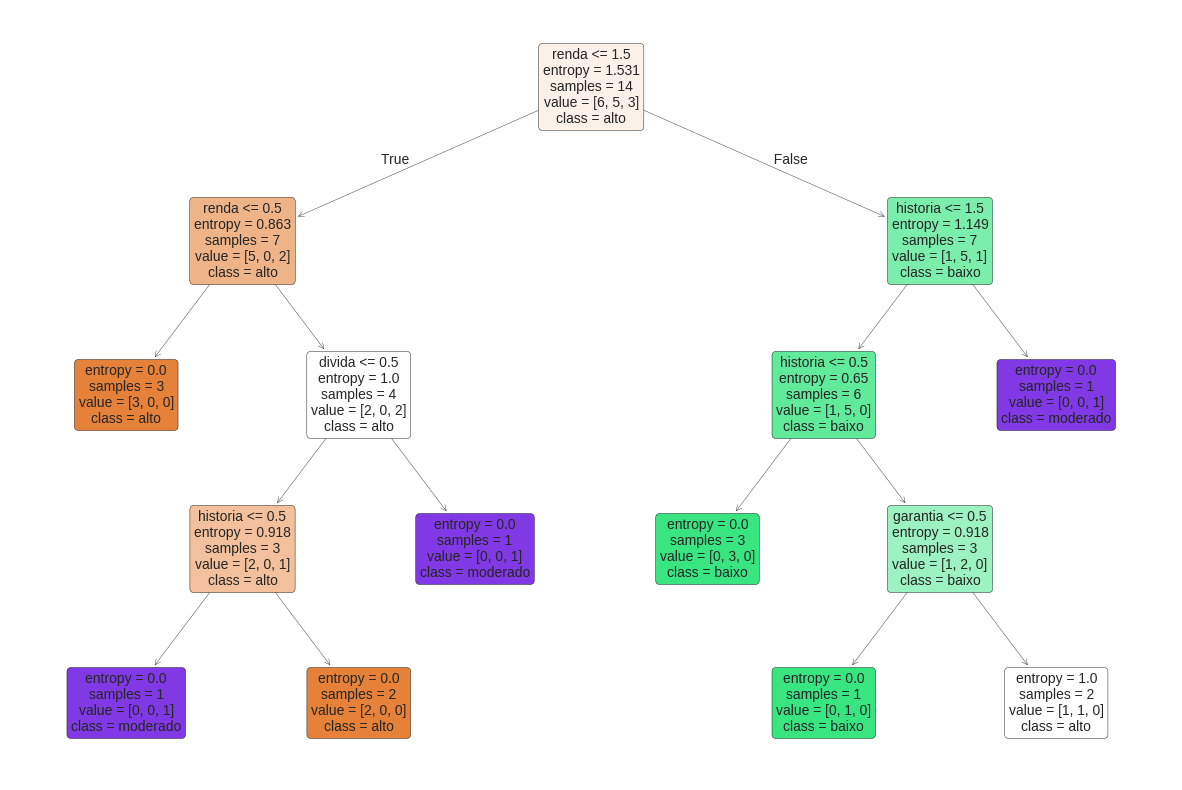

In [129]:
from sklearn import tree

plt.figure(figsize=(15,10))

tree.plot_tree(
  decision_tree=arvore_risco_credito,
  feature_names=FEATURE_NAMES,
  class_names=CLASS_NAMES,
  filled=True,
  rounded=True,
  fontsize=10
)

plt.show()

e) FAZER A PREVISÃO

Utilize .predict para fazer a previsão realizada no exemplo em sala.

   i. história boa, dívida alta, garantia nenhuma, renda > 35

   ii. história ruim, dívida alta, garantia adequada, renda < 15


Verifique nos slides se seu resultado está correto!

In [130]:
test_data = np.array([
    [0, 0, 1, 2], # história boa, dívida alta, garantia nenhuma, renda > 35
    [2, 0, 0, 0]  # história ruim, dívida alta, garantia adequada, renda < 15
])

predictions = arvore_risco_credito.predict(test_data)

print([CLASS_NAMES[p] for p in predictions])

['baixo', 'alto']


#3 - Algoritmo de Árvore de Decisão para uma base de dados maior (Credit Data)

Nesta seção você deverá testar o uso da Árvore de Decisão para a Base de Dados Credit Risk Dataset. Aqui estaremos analisando os clientes que pagam (classe 0) ou não pagam a dívida (classe 1), a fim do banco conceder empréstimo.

In [131]:
ATTRIBUTE_NAMES = ['renda', 'idade', 'emprestimo']
TARGET_NAMES = ['paga', 'nao paga']

In [132]:
# abrir o arquivo
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

a) Ao abrir o arquivo utilize .shape para verificar o tamanho dos dados de treinamento e de teste

OBS: os dados de treinamento devem ter as seguintes dimensões: x=(1500, 3), y=(1500,); os dados de teste devem ter as seguintes dimensões: x=(500, 3), y=(500,)

In [133]:
X_credit_treinamento.shape, y_credit_treinamento.shape, X_credit_teste.shape, y_credit_teste.shape

((1500, 3), (1500,), (500, 3), (500,))

b) Importe o pacote DecisionTreeClassifier do sklearn para treinar o seu algoritmo de árvore de decisão. Para poder refazer os testes e obter o mesmo resultado utilize o parâmetro random_state = 0.

In [134]:
credit_risk_classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)

arvore_credit = credit_risk_classifier.fit(X_credit_treinamento, y_credit_treinamento)

c) Faça a previsão com os dados de teste. Visualize os dados e verifique se as previsões estão de acordo com os dados de teste (respostas reais).

In [135]:
predictions_credit_risk = arvore_credit.predict(X_credit_teste)

d) Agora faça o cálculo da acurácia para calcular a taxa de acerto entre os valores reais (y teste) e as previsões

In [136]:
from sklearn.metrics import accuracy_score, classification_report

In [137]:
# Função utilitária para exibir erros em relação ao total e calcular acurácia
def calculate_accuracy(expected: np.ndarray, predictions: np.ndarray):
  count_diff = 0
  total = len(predictions)
  for i in range(total):
    if predictions[i] != expected[i]:
      count_diff += 1

  print(f'Previsões corretas:  {total - count_diff}/{total}')
  print(f'Previsões incorretas:  {count_diff}/{total}')
  print(f'Acurácia: {accuracy_score(expected, predictions)}')

In [138]:
calculate_accuracy(y_credit_teste, predictions_credit_risk)

Previsões corretas:  491/500
Previsões incorretas:  9/500
Acurácia: 0.982


e) Faça a análise da Matriz de Confusão.

i. Quantos clientes foram classificados corretamente que pagam a dívida?

ii. Quantos clientes foram classificados incorretamente como não pagantes?

iii. Quantos clientes foram classificados corretamente que não pagam?

iv. Quantos clientes foram classificados incorretamente como pagantes?

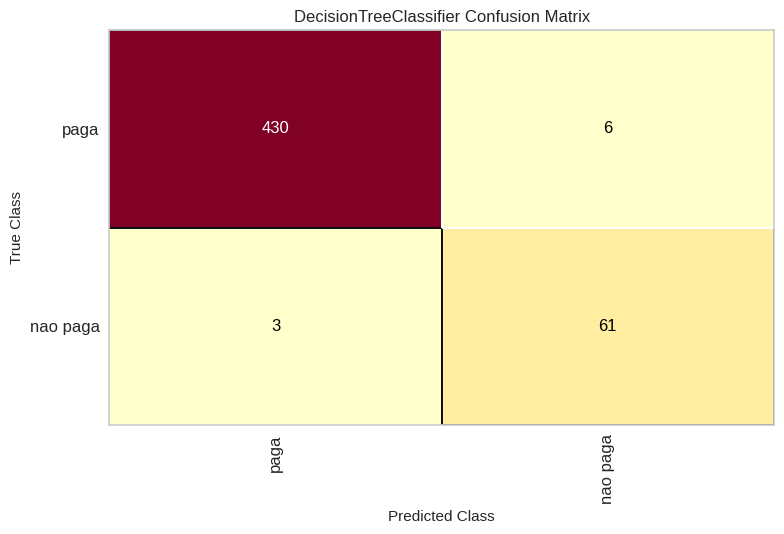

In [139]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(arvore_credit, classes=TARGET_NAMES)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)
cm.show()

plt.show()

In [140]:
# Acessa as células da matriz para apresentar os valores
cm_data = cm.confusion_matrix_

# i)
print(f'Clientes que pagam classificados corretamente: {cm_data[0][0]}')

# ii)
print(f'Clientes classificados incorretamente como não pagantes: {cm_data[0][1]}')

# iii)
print(f'Clientes que não pagam classificados corretamente: {cm_data[1][1]}')

# iv)
print(f'Clientes classificados incorretamente como pagantes: {cm_data[1][0]}')

Clientes que pagam classificados corretamente: 430
Clientes classificados incorretamente como não pagantes: 6
Clientes que não pagam classificados corretamente: 61
Clientes classificados incorretamente como pagantes: 3


f) Faça um print do parâmetro classification_report entre os dados de teste e as previsões. Explique qual é a relação entre precision e recall nos dados. Como você interpreta esses dados?

In [141]:
test_report = classification_report(
  y_credit_teste,
  predictions_credit_risk,
  target_names=TARGET_NAMES
)

print(f'Relatório com métricas: \n{test_report}')

Relatório com métricas: 
              precision    recall  f1-score   support

        paga       0.99      0.99      0.99       436
    nao paga       0.91      0.95      0.93        64

    accuracy                           0.98       500
   macro avg       0.95      0.97      0.96       500
weighted avg       0.98      0.98      0.98       500



A análise da matriz de confusão através de métricas é muito útil para avaliar performance contextual em problemas de classificação binária.

A precisão avalia os exemplos corretamente classificados como positivos dentro das predições, sendo relevante quando se quer evitar falsos positivos. Já o recall mede a proporção de verdadeiros positivos corretamente classificados em relação aos positivos reais e é relevante quando se quer evitar falsos negativos.

Nessa situação, uma pessoa que não pagaria sendo classificada como pagante gera significativamente mais prejuízo do que uma pessoa que pagaria sendo classificada como não pagante — um falso negativo para a classe "nao paga". Isso significa que a métrica de recall para a classe "nao paga" é a métrica mais relevante.

Para a classe "paga", houve precisão e recall de 99%, ou seja, praticamente todos os clientes classificados como pagantes realmente pagam, e quase todos os pagantes reais foram corretamente identificados.

Para a classe "nao paga", o desempenho foi em geral mais baixo, indicando que 91% dos exemplos classificados como não pagantes realmente o são, e 95% de todos os não pagantes reais foram identificados.

g) Gere uma visualização da sua árvore de decisão utilizando o pacote tree da biblioteca do sklearn.

OBS 1: Os atributos previsores são = ['income', 'age', 'loan']

OBS 2: Adicione cores, nomes para os atributos e para as classes. Você pode utilizar a função fig.savefig para salvar a árvore em uma imagem .png

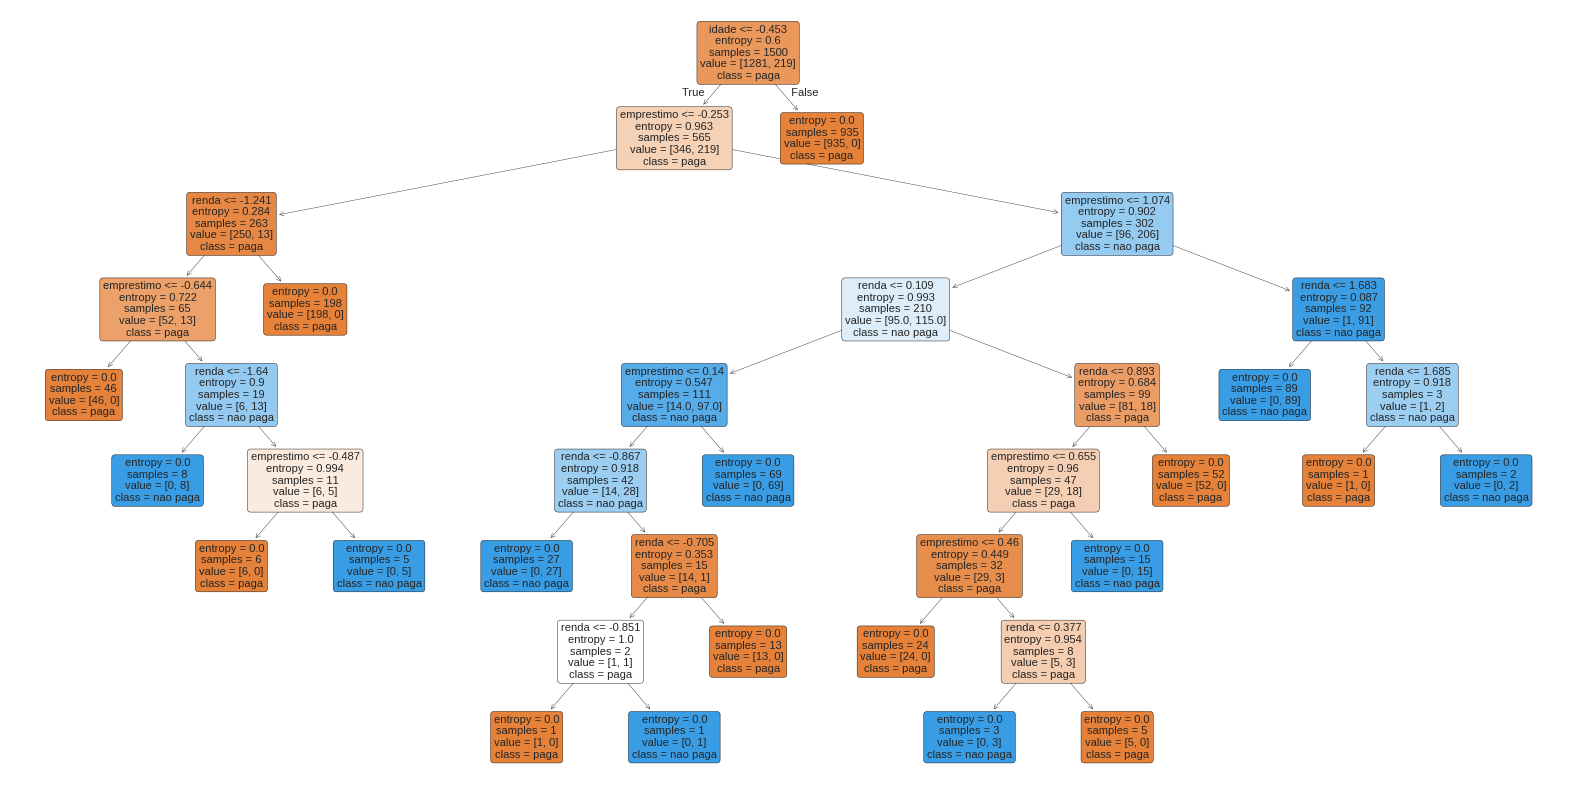

In [142]:
# Plota a árvore de decisão
plt.figure(figsize=(20,10))
tree.plot_tree(
  decision_tree=arvore_credit,
  feature_names=ATTRIBUTE_NAMES,
  class_names=TARGET_NAMES,
  filled=True,
  rounded=True,
  fontsize=8
)

plt.show()

# Algoritmo Random Forest

Nesta seção iremos utilizar o algoritmo Random Forest para a mesma base de crédito (**Credit Risk Dataset**) - arquivo *credit.pkl*.

a) Importe o pacote RandomForestClassifier do sklearn para treinar o seu algoritmo de floresta randomica.

In [143]:
from sklearn.ensemble import RandomForestClassifier

b) Para gerar a classificação você deve adicionar alguns parâmetros:
*   n_estimators=10  --> número de árvores que você irá criar
*   criterion='entropy'
*   random_state = 0

In [144]:
random_forest_classifier = RandomForestClassifier(
  n_estimators=10,
  criterion='entropy',
  random_state=0
)

forest_credit = random_forest_classifier.fit(X_credit_treinamento, y_credit_treinamento)

c) Faça a previsão com os dados de teste. Visualize os dados e verifique se as previsões estão de acordo com os dados de teste (respostas reais).

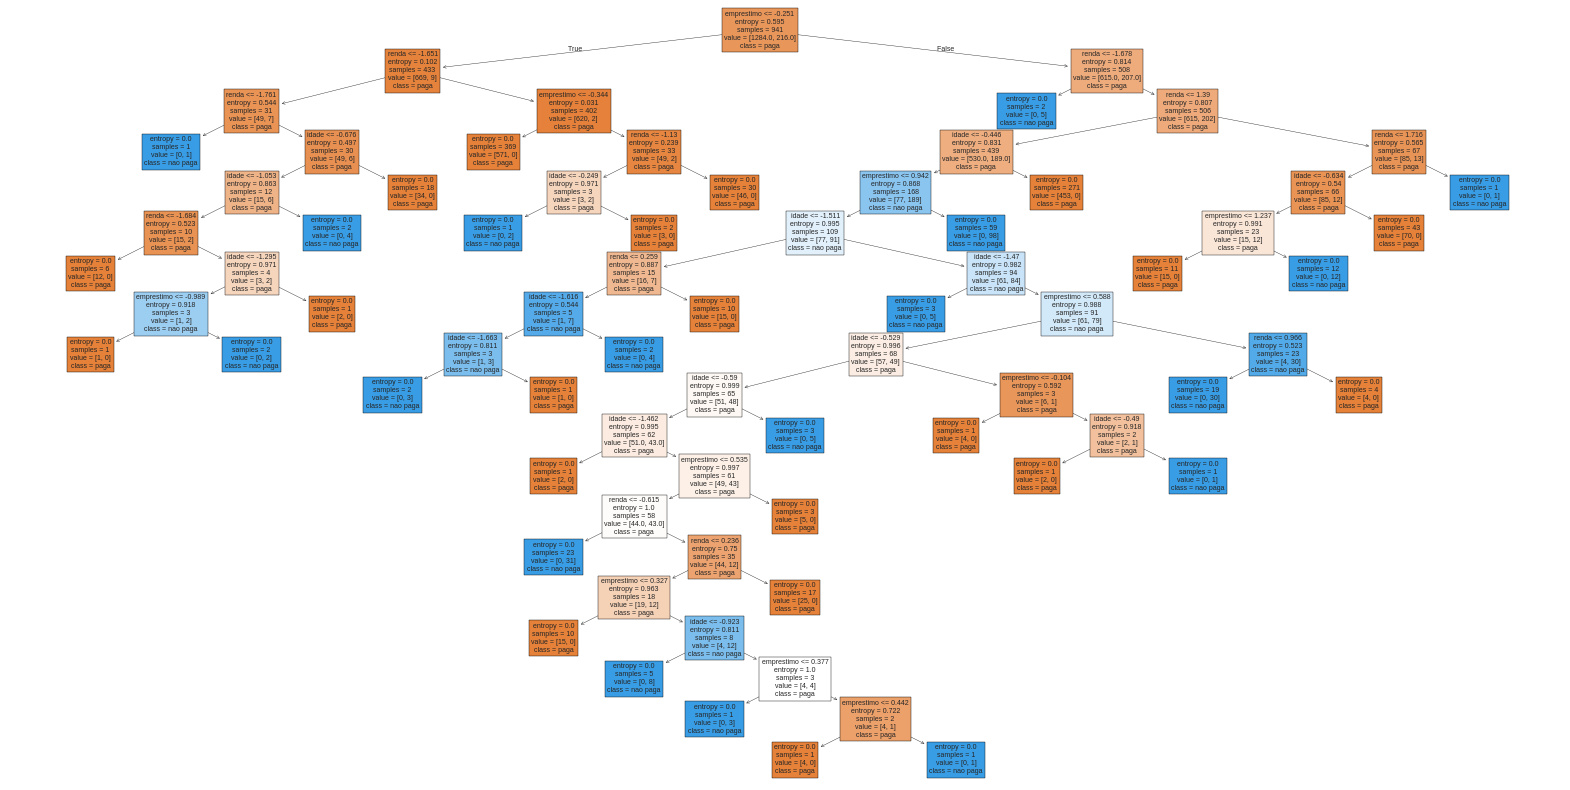

In [145]:
# Plota 1ª árvore gerada da floresta
plt.figure(figsize=(20,10))
tree.plot_tree(
  random_forest_classifier.estimators_[0],
  feature_names=ATTRIBUTE_NAMES,
  class_names=TARGET_NAMES,
  filled=True
)
plt.show()

In [146]:
# Previsão com floresta da análise de crédito
predictions_credit_forest = forest_credit.predict(X_credit_teste)

d) Agora faça o cálculo da acurácia para calcular a taxa de acerto entre os valores reais (y teste) e as previsões. O resultado foi melhor do que a árvore de decisão simples?

In [147]:
calculate_accuracy(y_credit_teste, predictions_credit_forest)

Previsões corretas:  484/500
Previsões incorretas:  16/500
Acurácia: 0.968


A acurácia da floresta (0.968) foi menor que a da árvore simples (0.982), ou seja, o resultado da árvore de decisão simples foi melhor nessa métrica.

e) Se o resultado foi inferior, como você poderia resolver isso? Quais foram os resultados obtidos?

Como o resultado foi inferior, após análise da primeira árvore da floresta com 10 árvores, observaram-se muitas folhas com apenas uma amostra, o que poderia estar afetando a classificação por pequenas variações, como ruídos ou outliers. Por isso, optou-se por definir um número mínimo de amostras por folha, de modo a podar esses ruídos da classificação final. O número que demonstrou melhor aumento da acurácia (96,8% -> 97,8%) foi de 8 amostras por folha.

Como apenas esse parâmetro não foi suficiente, preferiu-se aumentar o número de árvores da floresta, que é uma prática comum na utilização do algoritmo para aumentar a sensibilidade. Foram testados valores de 5 em 5: 10, 15, 20, 25 e 30. Ainda que a melhor acurácia, de 98,2%, tenha sido atingida já com 15 árvores, mantivemos o número de 30, que gerou a mesma acurácia, por ser um valor mais seguro quanto à sensibilidade da floresta.

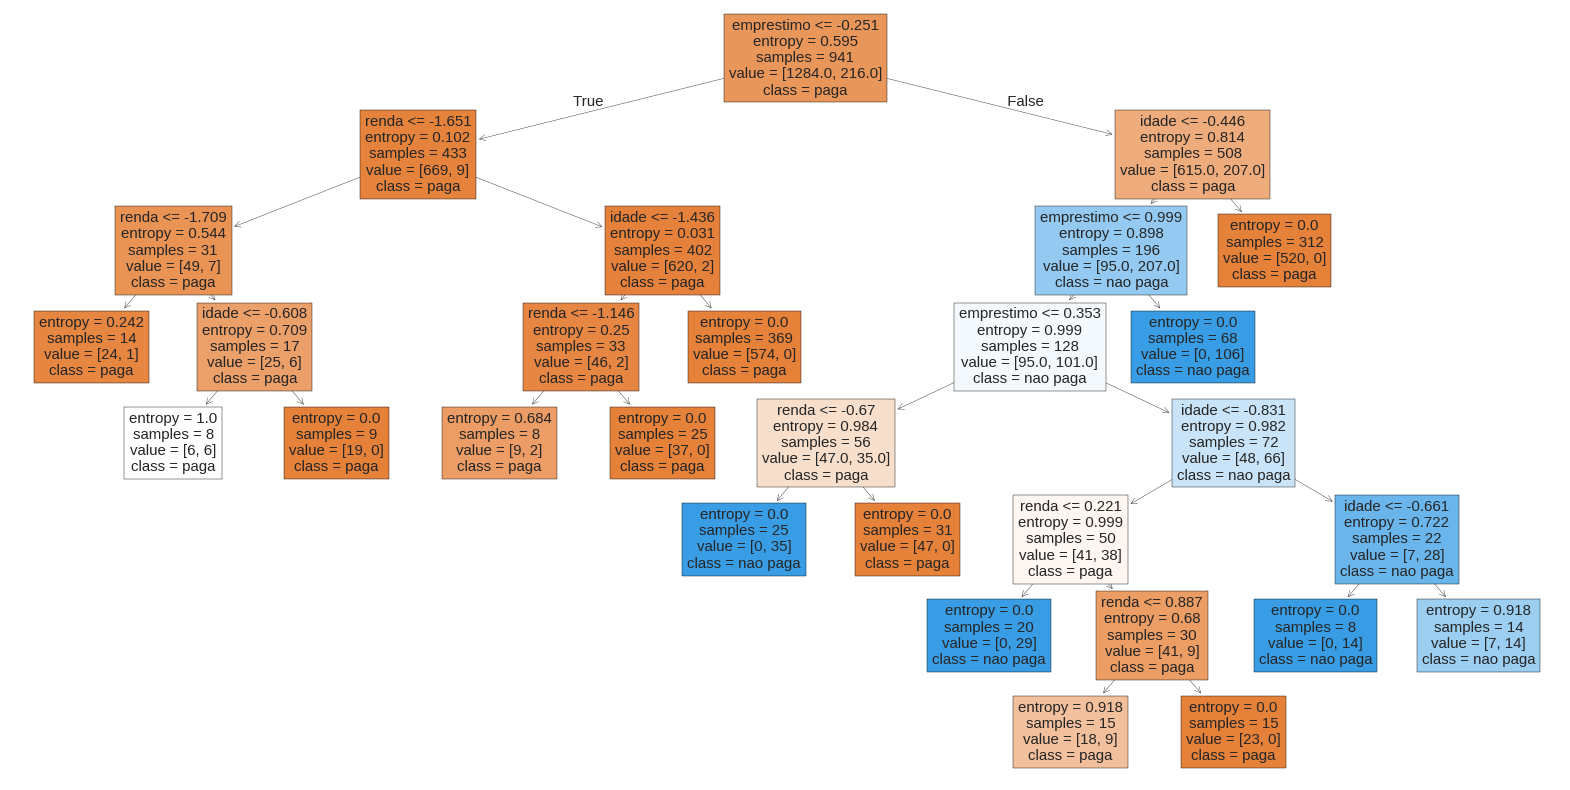

In [148]:
# Ajuste do número de árvores e nº de amostras por folha
random_forest_classifier = RandomForestClassifier(
  n_estimators=30,
  criterion='entropy',
  random_state=0,
  min_samples_leaf=8,
)

# Treinamento com ajuste de árvores e mínimo de nós
forest_credit = random_forest_classifier.fit(X_credit_treinamento, y_credit_treinamento)

# Plota 1ª árvore gerada da floresta
plt.figure(figsize=(20,10))
tree.plot_tree(
  random_forest_classifier.estimators_[0],
  feature_names=ATTRIBUTE_NAMES,
  class_names=TARGET_NAMES,
  filled=True
)
plt.show()

In [149]:
predictions_credit_forest = forest_credit.predict(X_credit_teste)
credit_accuracy = calculate_accuracy(y_credit_teste, predictions_credit_forest)

print(f'Acurácia da floresta:  {credit_accuracy}')

Previsões corretas:  491/500
Previsões incorretas:  9/500
Acurácia: 0.982
Acurácia da floresta:  None


f) Faça a análise da Matriz de Confusão.

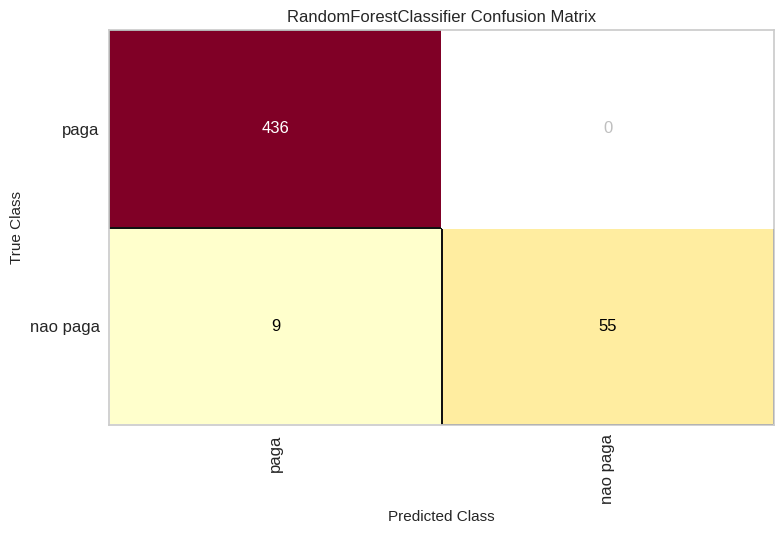

In [150]:
cm = ConfusionMatrix(forest_credit, classes=TARGET_NAMES)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)
cm.show()

plt.show()

In [151]:
# Acessa as células da matriz para apresentar os valores
cm_data = cm.confusion_matrix_

# i)
print(f'Clientes que pagam classificados corretamente: {cm_data[0][0]}')

# ii)
print(f'Clientes classificados incorretamente como não pagantes: {cm_data[0][1]}')

# iii)
print(f'Clientes que não pagam classificados corretamente: {cm_data[1][1]}')

# iv)
print(f'Clientes classificados incorretamente como pagantes: {cm_data[1][0]}')

Clientes que pagam classificados corretamente: 436
Clientes classificados incorretamente como não pagantes: 0
Clientes que não pagam classificados corretamente: 55
Clientes classificados incorretamente como pagantes: 9


g) Faça um print do parâmetro classification_report entre os dados de teste e as previsões. Explique qual é a relação entre precision e recall nos dados. Como você interpreta esses dados?

In [152]:
test_report = classification_report(
  y_credit_teste,
  predictions_credit_forest,
  target_names=TARGET_NAMES
)

print(f'Relatório com métricas: \n{test_report}')

Relatório com métricas: 
              precision    recall  f1-score   support

        paga       0.98      1.00      0.99       436
    nao paga       1.00      0.86      0.92        64

    accuracy                           0.98       500
   macro avg       0.99      0.93      0.96       500
weighted avg       0.98      0.98      0.98       500



Para a classe "paga", houve precisão de 98% e recall de 100%, ou seja, praticamente todos os clientes classificados como pagantes realmente pagam (coluna 1), e todos os pagantes reais foram corretamente identificados (linha 1). Nesse caso, o resultado de 100% indica que não houve equívocos (0/436).

Para a classe "nao paga", o desempenho de precisão foi maior, com 100% dos exemplos de não pagantes classificados como tal (coluna 2), e, quanto ao recall, teve um desempenho menor, onde 86% de todos os não pagantes reais foram identificados (linha 2). Isso provavelmente tem relação com o número de amostras da classe, que é muito inferior ao total da classe "paga", visto que o algoritmo da Random Forest pode ser sensível ao desbalanceamento entre classes.

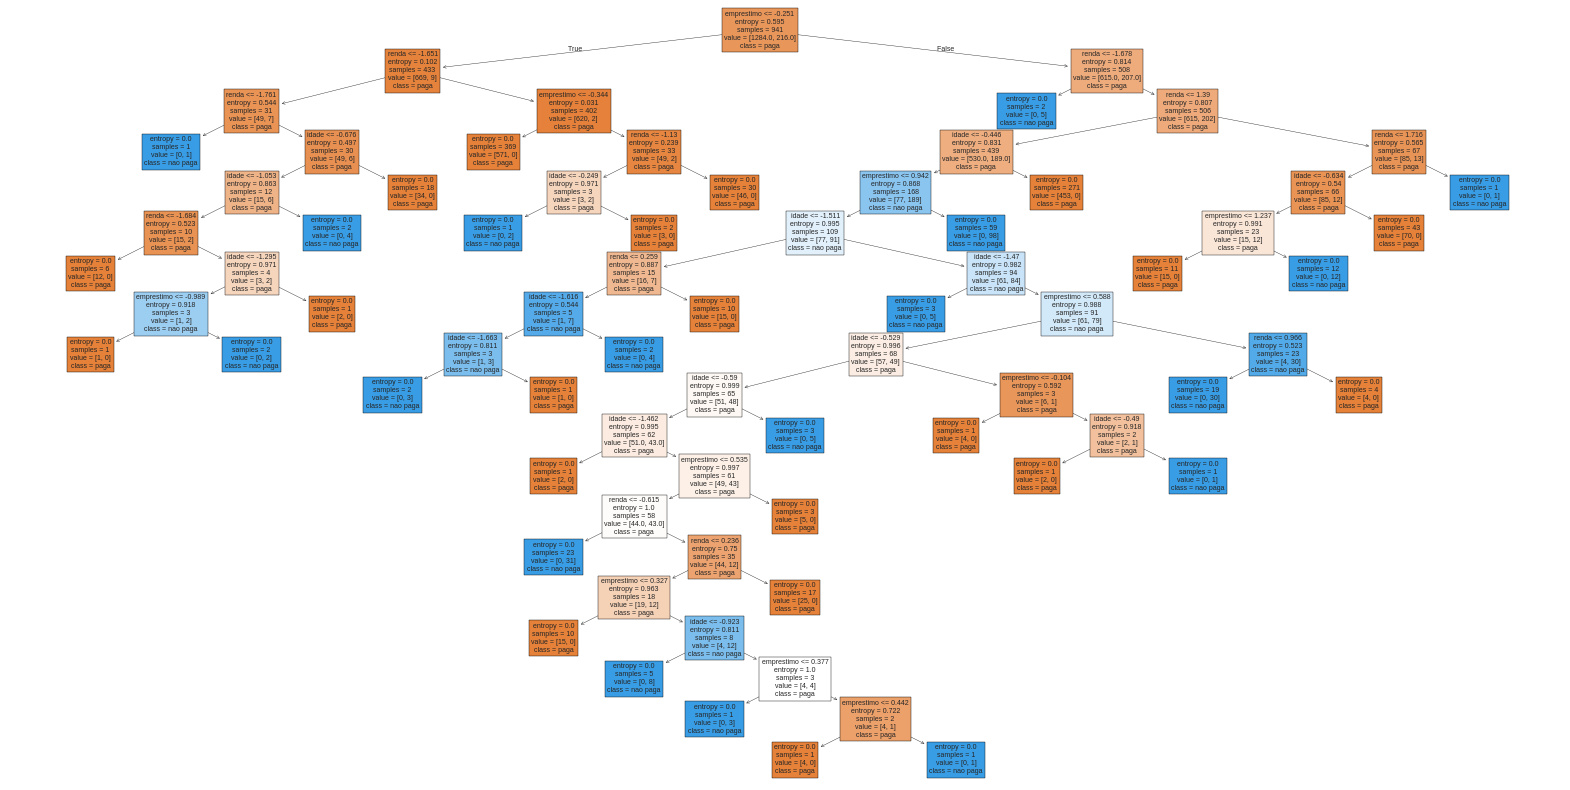

In [153]:
# Usando 40 árvores sem restringir amostras por folha
random_forest_classifier = RandomForestClassifier(
  n_estimators=40,
  criterion='entropy',
  random_state=0
)

# Treinamento com ajuste de nº de árvores
forest_credit = random_forest_classifier.fit(X_credit_treinamento, y_credit_treinamento)

# Plota 1ª árvore gerada da floresta
plt.figure(figsize=(20,10))
tree.plot_tree(
  random_forest_classifier.estimators_[0],
  feature_names=ATTRIBUTE_NAMES,
  class_names=TARGET_NAMES,
  filled=True
)
plt.show()

In [154]:
predictions_credit_forest = forest_credit.predict(X_credit_teste)

calculate_accuracy(y_credit_teste, predictions_credit_forest)

Previsões corretas:  492/500
Previsões incorretas:  8/500
Acurácia: 0.984


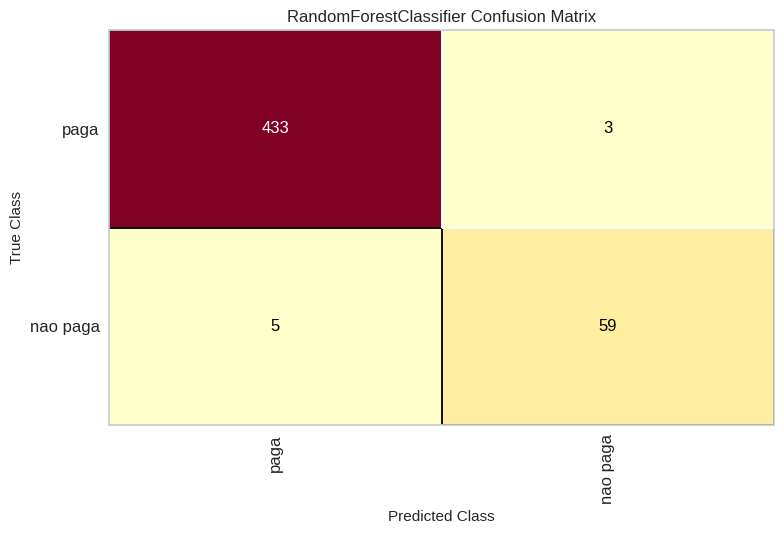

In [155]:
cm = ConfusionMatrix(forest_credit, classes=TARGET_NAMES)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)
cm.show()

plt.show()

In [156]:
# Acessa as células da matriz para apresentar os valores
cm_data = cm.confusion_matrix_

# i)
print(f'Clientes que pagam classificados corretamente: {cm_data[0][0]}')

# ii)
print(f'Clientes classificados incorretamente como não pagantes: {cm_data[0][1]}')

# iii)
print(f'Clientes que não pagam classificados corretamente: {cm_data[1][1]}')

# iv)
print(f'Clientes classificados incorretamente como pagantes: {cm_data[1][0]}')

Clientes que pagam classificados corretamente: 433
Clientes classificados incorretamente como não pagantes: 3
Clientes que não pagam classificados corretamente: 59
Clientes classificados incorretamente como pagantes: 5


In [157]:
test_report = classification_report(
  y_credit_teste,
  predictions_credit_forest,
  target_names=TARGET_NAMES
)

print(f'Relatório com métricas: \n{test_report}')

Relatório com métricas: 
              precision    recall  f1-score   support

        paga       0.99      0.99      0.99       436
    nao paga       0.95      0.92      0.94        64

    accuracy                           0.98       500
   macro avg       0.97      0.96      0.96       500
weighted avg       0.98      0.98      0.98       500



Nesse caso, para a classe "paga", houve precisão e recall de 99%, ou seja, praticamente todos os clientes classificados como pagantes realmente pagam (coluna 1), e também quase todos os pagantes reais foram corretamente identificados (linha 1).

Para a classe "nao paga", o desempenho foi mais equilibrado do que com 30 árvores e limite de folhas, com 95% dos exemplos de não pagantes classificados como tal (coluna 2), e, quanto ao recall, teve um desempenho consideravelmente maior, onde 92% de todos os não pagantes reais foram identificados (linha 2).

Assim, entende-se que, apesar de não ter nenhuma métrica totalmente perfeita como o experimento anterior, o desempenho do modelo é melhor em pontos mais relevantes, como o recall para "nao paga". Como métrica geral, a acurácia da floresta também foi maior nesse caso: 98,4%.